# Math Modelling Project

## The trajectory of a projectile

An airgun shot a pellet with a mass $m$ at an angle $\theta$ into the air. The speed of the pellet is $v_0$ and the position is $(0, y_0)$ when it leaves the barrel. Assuming the air resistance is proportional to the velocity with a coefficient $r$. Let $x(t)$ and $y(t)$ be the horizontal and vertical position (i.e, the x- and y-coordinates) of the pellet at time $t$.

* The horizontal direction: the air resistance is the only force. According to Newton's second law of motion, 
$$\ddot x(t) = -\frac{r}{m}\dot x(t)$$

* The vertical direction: two forces act on the pellet, the air resistance and the gravity. Let $g$ be the gravitational constant, 
$$\ddot y(t) = -g -\frac{r}{m}\dot y(t)$$

The trajectory is the parametric curve $(x(t), y(t))$. Find the solutions $x(t)$ and $y(t)$ using symbolic calculations. 


In [1]:
from sympy import *
from matplotlib.pyplot import plot
from scipy.optimize import fsolve
from sympy.abc import r,m,t,theta

x = Function("x")
y = Function("y")
v0,y0,g = symbols("v0, y0, g", real=True)

In [3]:

# from scipy.constants import g
hd = diff(x(t), t, 2)+r*diff(x(t),t,1)/m
vd = diff(y(t), t, 2)+g+r*diff(y(t),t,1)/m
display(hd)
display(vd)
sol_hd = dsolve(hd, ics={x(0):0, x(t).diff("t").subs({t:0}):v0*cos(theta)})
display(sol_hd)
sol_vd = dsolve(vd, ics={y(0):y0, y(t).diff("t").subs({t:0}):v0*sin(theta)})
display(sol_vd)

speed_hd = diff(x(t), t, 1)+r*x(t)/m
speed_vd = diff(y(t), t, 1)+g+r*y(t)/m
vx = dsolve(speed_hd, ics={x(0):v0*cos(theta)})
display(vx)
vy = dsolve(speed_vd, ics={y(0):v0*sin(theta)})
display(vy)
v = sqrt(vx.args[1]*vx.args[1]+vy.args[1]*vy.args[1]) 
display(v)

Derivative(x(t), (t, 2)) + r*Derivative(x(t), t)/m

g + Derivative(y(t), (t, 2)) + r*Derivative(y(t), t)/m

Eq(x(t), m*v0*cos(theta)/r - m*v0*exp(-r*t/m)*cos(theta)/r)

Eq(y(t), -g*m*t/r + (-g*m**2 - m*r*v0*sin(theta))*exp(-r*t/m)/r**2 + (g*m**2 + m*r*v0*sin(theta) + r**2*y0)/r**2)

Eq(x(t), v0*exp(-r*t/m)*cos(theta))

Eq(y(t), (-g*m + exp(r*(log(g*m + r*v0*sin(theta))/r - t/m)))/r)

sqrt(v0**2*exp(-2*r*t/m)*cos(theta)**2 + (-g*m + exp(r*(log(g*m + r*v0*sin(theta))/r - t/m)))**2/r**2)

## Maximum range

Consider the following parameter values: the friction coefficient $r=0.001$, the mass of the pellet is $m=14.3$ grain $\approx 9.3\times 10^{-4}$ kilogram, the initial position of the pellet is $x_0=0$, $y_0=2$, the initial velocity is $v_0=274$ meters per second.

For any given $\theta$, numerically find the time $T$ the pellet hitting the ground, i.e., $y(T)=0$. In general, this defines a numerical function $T(\theta)$. The maximum range is $R_M=x(T)$.

Note that, because $T$ is a function of $\theta$, so is $R_M$. Plot $R_M(\theta)$ for $0\leq\theta\leq90^\circ$

* Hint: The function $y(t)=0$ cannot be solved symbolically as this is a transcendental function. You need to solve it numerically, e.g., using **fsolve**.

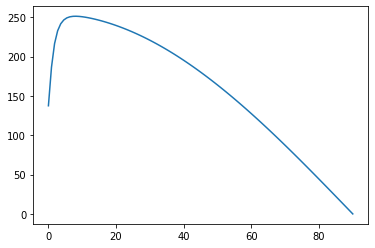

In [19]:
from numpy import *
x_position = lambdify((t,theta),sol_hd.args[1].subs({r:0.001, m:9.3e-4, v0:274}))
y_position = lambdify((t,theta),sol_vd.args[1].subs({r:0.001, m:9.3e-4, v0:274, y0:2, g:9.81}))
theta_range = linspace(0, 90, 100)
T_range = zeros((100))
R_range = zeros((100))
i = 0
for degree in theta_range:
  solution_t = fsolve(y_position, [5], args=(degree/180*pi))
  T_range[i] = solution_t[0]
  R_range[i] = x_position(solution_t[0],degree/180*pi)
  i = i+1

plot(theta_range,R_range)

## Effective range

The speed of a pellet can be computed as
$$
v(t) = \sqrt{\dot x^2(t)+\dot y^2(t)}
$$

A pellet can penetrate human skin at a speed about 100 meters/second.  Find the largest time $T_e$ such that
$v(T_e)\geq100$ and $y(T_e)\geq0$. Then the effective range is

$$R_e = \sqrt{x^2(T_e)+y^2(T_e)}$$

Plot $R_e$ as a function of $\theta$ for $0\leq\theta\leq15^\circ$

* Hint: $T_e$ is the earlier one of the two time $T_{100}$ when $v(T_{100})=100$ and $T_M$ when the pellet hit the ground.

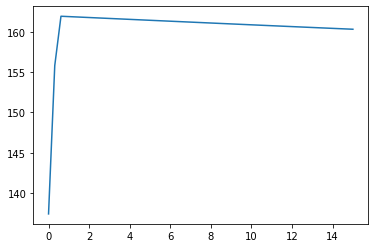

In [24]:
v_function = lambdify((t,theta),v.subs({r:0.001, m:9.3e-4, v0:274, y0:2, g:9.81})-100)
theta_range = linspace(0, 15, 50)
Te_range = zeros((50))
T_range = zeros((50))
Re_range = zeros((50))
i = 0
guess = 0
for degree in theta_range:
  solution_t = fsolve(y_position, [5], args=(degree/180*pi))
  T_range[i] = solution_t[0]
  solution_te = fsolve(v_function, [guess], args=(degree/180*pi))
  Te_range[i] = solution_te[0]
  guess = solution_te[0]
  time = min(solution_t[0],solution_te[0])
  Re_range[i] = sqrt(x_position(time,degree/180*pi)**2+y_position(time,degree/180*pi)**2)
  i = i+1

plot(theta_range,Re_range)

## Animation

Make an animation showing how the trajectory changes with $\theta$, for $\theta=0^\circ, 1^\circ, ..., 45^\circ$. For each frame (a $\theta$ value), plot two curves:
* the full trajectory as a blue curve, i.e., parametric curve $(x(t), y(t))$ for $0\leq t\leq T$ until the pellet hit the ground at time $T$.
* the effective part of the trajectory as a red curve, i.e., $(x(t), y(t))$ for $0\leq t\leq T_e$ until the pellet has a velocty equal to 100 meters per second at time $T_e$.

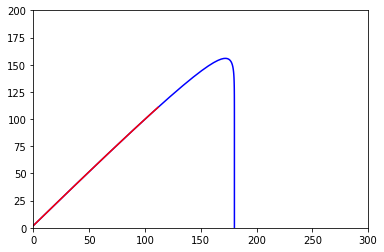

In [26]:
from matplotlib.pyplot import subplots
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
fig, ax = subplots()
blue, = ax.plot([], [], 'b')
red, = ax.plot([], [], 'r')

def init():
  ax.set_xlim(0, 300)
  ax.set_ylim(0, 200)
  return blue,red,

def update(degree):
  solution_t = fsolve(y_position, [5], args=(degree/180*pi))
  x_blue = x_position(linspace(0,solution_t[0],100),degree/180*pi)
  y_blue = y_position(linspace(0,solution_t[0],100),degree/180*pi)
  blue.set_data(x_blue, y_blue)

  solution_te = fsolve(v_function, [0.2], args=(degree/180*pi))
  if solution_t[0]<solution_te[0]:
    red.set_data(x_blue, y_blue)
  else:
    x_red = x_position(linspace(0,solution_te[0],100),degree/180*pi)
    y_red = y_position(linspace(0,solution_te[0],100),degree/180*pi)
    red.set_data(x_red, y_red)
  return blue,red,

ani = FuncAnimation(fig, update, frames=linspace(0, 45, 128),
              init_func=init, blit=True)

HTML(ani.to_html5_video())